This notebook primarily details the evaluation protocol and testing procedures of the proposed model. It also provides instructions on how to use the trained model for inference and reproduction of the reported results.

The complete implementation, including model training and full experimental pipelines, will be made publicly available upon acceptance of the manuscript.

## Performance on GSC dataset

### Data Generation

We construct a simulated acoustic dataset using speech signals from the 
Google Speech Commands (GSC) dataset as sound sources. 
Room acoustics simulation is performed using the Pyroomacoustics toolkit.

#### Room Configuration
- Room size: \( 7 \* 7 \* 3 \) meters  
- Reverberation: simulated using the image-source method  
- Additive noise level: SNR = 30 dB  
- Sampling rate: 16 kHz  

#### Source Configuration
The sound source is randomly positioned within:
- Distance range: 0.5 m – 2.0 m from the microphone array  
- Azimuth angle: 0° – 359° (1° resolution)

#### Dataset Split
For each azimuth angle:
- 100 samples are generated for training  
- 25 samples are generated for testing  

This results in a uniformly distributed angular dataset for supervised 
direction-of-arrival (DOA) estimation.

In [6]:
from dataset.data_creation import data_generation
import pyroomacoustics as pra
dataset = pra.datasets.GoogleSpeechCommands(basedir='./data/google_speech_commands',download=True)  # Set to True if have not downloaded
selected_word = ['one','two','three','four','five','six','seven','eight','nine','zero']
matches = dataset.filter(word=selected_word)
print(matches)
print("Number of '%s' samples : %d" % (selected_word, len(matches)))
for num_source in range(1,2):
    print(f"Generating source {num_source}")
    data_generation(num_source=num_source,dataset=dataset,train=True,cohenet=True, save_dir='./GSC_data/train/coherent/')

### Self-Supervised Spatial Correlation Learning (SSCL)

To enhance spatial representation learning without requiring labeled data, we introduce a Self-Supervised Spatial Correlation Learning (SSCL) module. The objective is to learn microphone array spatial structures by modeling inter-channel correlations from unlabeled recordings.

During pretraining, the model is optimized for 400 epochs using the Adam optimizer with a CosineAnnealingLR scheduler. This self-supervised initialization encourages the network to encode geometry-consistent spatial features, facilitating improved robustness and generalization in downstream sound source localization tasks.

In [7]:
from dataset.data_loader import GSP_Loader_pretrain
from model.NeuralMusic import NeuralMusic_pretrain 
from utlis.jupyter_utils import plot_spec_reconstruction
import torch
import numpy as np
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

data_dir = '/media/kemove/T9/sound_source_loc/simulation_data'
val_dataset_pretrain   = GSP_Loader_pretrain(root=data_dir,subset="val",noise_aug=False,coherent=2)
pretrain_model = NeuralMusic_pretrain().to(device)
pretrain_path = '/media/kemove/T9/sound_source_loc/simulation_data/new_exp/saved_simulation/pretrain_new/simulation/last_model'
pretrain_model.load_state_dict(torch.load(pretrain_path),strict=False)
pretrain_model.eval()
print("The pretrained weights are loaded")

The pretrained weights are loaded


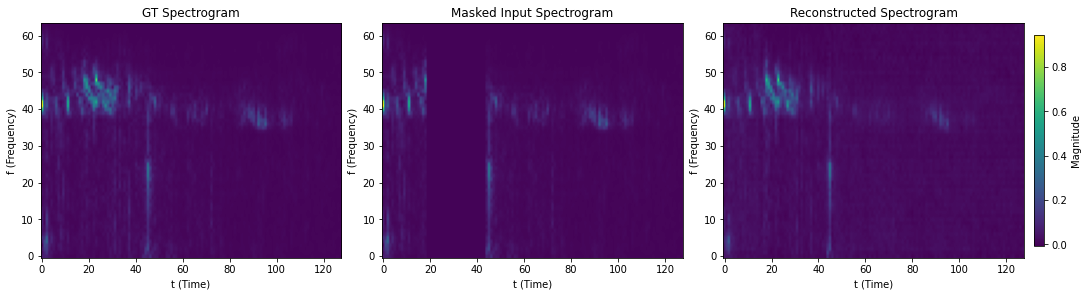

In [29]:
plot_spec_reconstruction(
    dataset=val_dataset_pretrain,
    model=pretrain_model,
    device=device,
    index=7,
    freq_frac=0.5
)

### DOA Estimation with NeuralMUSIC

This section demonstrates DOA estimation under both known (M = 1) and unknown source-number settings.

Minor numerical differences from the results reported in the paper may occur due to randomness and implementation details, but the overall behavior remains consistent.

In [30]:
from dataset.data_loader import GSC_Loader
from model.NeuralMusic import NeuralMusic 
import os
import torch
import numpy as np
torch.multiprocessing.set_sharing_strategy('file_system') 
from torch import nn
import librosa
import sys
from scipy.signal import find_peaks
from tqdm import tqdm
from torch.utils.data import DataLoader
import warnings
warnings.filterwarnings("ignore")
from itertools import permutations
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

def angular_mae_loss_optimized(predictions, ground_truths):

    batch_size = predictions.shape[0]
    total_loss = 0

    for i in range(batch_size):
        pred = predictions[i]  
        gt = ground_truths[i]  
        best_loss = float('inf')
        for perm in permutations(pred): 
            perm = np.array(perm) 
            angle_diff = (perm - gt + 180) % 360 - 180  
            loss = np.mean(np.abs(angle_diff))  
            best_loss = min(best_loss, loss)  

        total_loss += best_loss 

    return total_loss / batch_size 
    
def evaluate_ours_known(val_loader,M,device):
    predictions = []
    ground_truths = []
    probs = []
    for i, (test_sample, gt, sv, correlation) in enumerate(tqdm(val_loader)):
        test_sample, sv, correlation = test_sample.to(device), sv.to(device), correlation.to(device)
        with torch.no_grad():
            output = model(test_sample, sv, correlation)[1].squeeze(0).cpu().numpy()
            peaks, _ = find_peaks(output, height=0.1, distance=5)
            K = M
            topk_indices = peaks[np.argsort(output[peaks])[-K:]]
            if len(topk_indices) < K:
                max_index = np.argmax(output)
                topk_indices = np.array([max_index] * K)
            topk_indices = np.sort(topk_indices)
            probs.append(output)
            predictions.append(topk_indices)
            ground_truths.append(gt.squeeze(0).cpu().numpy())
        del test_sample, sv, correlation, output
        if i % 100 == 0:
            torch.cuda.empty_cache()
    predictions_array = np.array(predictions) % 360
    ground_truths_array = np.array(ground_truths) % 360
    probs = np.array(probs)
    if M==1:
        maae = np.mean(np.abs((predictions_array - ground_truths_array + 180) % 360 - 180))
    else:
        maae = angular_mae_loss_optimized(predictions_array,ground_truths_array)
    print(f"Test under {M} source setting. The MAAE is {maae}")
    return predictions,ground_truths,probs


In [31]:
N, T = 4,1600
input_channel = 8
data_dir = '/media/kemove/T9/sound_source_loc/simulation_data'
mic_offset = np.array([[ 45.7/1000/2, 45.7/1000/2, 0.0],
                    [ -45.7/1000/2,  45.7/1000/2, 0.0],
                    [-45.7/1000/2,  -45.7/1000/2, 0.0],
                    [45.7/1000/2,  -45.7/1000/2, 0.0]])

for M in [1,2]:
    val_dataset= GSC_Loader(root=data_dir,mic_offsets=mic_offset,subset="val",model='CNN',time_aug=False,coherent=1,num_source=M)
    val_loader = DataLoader(val_dataset, batch_size=1, shuffle=False, num_workers=4)
    model      = NeuralMusic(N, T, M,device=device,input_channel=input_channel).to(device)
    model_path = f'/media/kemove/T9/sound_source_loc/simulation_data/3-31/saved_simulation_attention_new/ours_1.0_1_{M}/best_model'
    model.load_state_dict(torch.load(model_path),strict=False)
    model.eval()
    predictions,ground_truths,probs = evaluate_ours_known(val_loader,M,device)

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 14400/14400 [00:54<00:00, 265.43it/s]


Test under 1 source setting. The MAAE is 1.3923611111111112


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 14400/14400 [01:02<00:00, 232.11it/s]


Test under 2 source setting. The MAAE is 2.2527083333333335


### TSNE-Plots
Compared with baseline methods that produce fragmented clusters, NeuralMUSIC forms a smooth and continuous manifold, where neighboring angular directions are arranged sequentially, revealing a clear circular topology consistent with azimuth periodicity. 
This structured embedding preserves angular continuity and contributes to more stable localization and improved generalization.

In [32]:
from sklearn.manifold import TSNE
from utlis.jupyter_utils import plot_tsne_clusters, plot_tsne_clusters_multi
import numpy as np

N, T, M = 4,1600,1
input_channel = 8
extracted_feature = {}
data_dir = '/media/kemove/T9/sound_source_loc/simulation_data'
mic_offset = np.array([[ 45.7/1000/2, 45.7/1000/2, 0.0],
                    [ -45.7/1000/2,  45.7/1000/2, 0.0],
                    [-45.7/1000/2,  -45.7/1000/2, 0.0],
                    [45.7/1000/2,  -45.7/1000/2, 0.0]])

def hook_fn(module, input, output):
    extracted_feature["rx"] = output.detach().clone()  # shape: [B, 2F, M*M]

model      = NeuralMusic(N, T, M,device=device,input_channel=input_channel).to(device)
model_path = f'/media/kemove/T9/sound_source_loc/simulation_data/3-31/saved_simulation_attention_new/ours_1.0_1_{M}/best_model'
model.load_state_dict(torch.load(model_path),strict=False)
model.eval()

val_dataset= GSC_Loader(root=data_dir,mic_offsets=mic_offset,subset="val",model='CNN',time_aug=False,coherent=1,num_source=M)
val_loader = DataLoader(val_dataset, batch_size=1, shuffle=False, num_workers=4)

rx_features = []
rx_labels = []
svs = []
handle = model.fc.register_forward_hook(hook_fn)
for i, (test_sample, gt, sv, correlation) in enumerate(tqdm(val_loader)):
    test_sample, sv, correlation = test_sample.to(device), sv.to(device), correlation.to(device)
    gt_np = gt.cpu().numpy()
    for j in range(gt_np.shape[0]):
        doa = gt_np[j]
        if int(doa) % 10 == 0:  # 仅偶数角度
            with torch.no_grad():
                _ = model(test_sample, sv, correlation)
                rx = extracted_feature["rx"]  
                rx_j = rx[j]  # [2F, M*M]
                rx_vec = rx_j.view(-1).cpu().numpy()  #
                rx_features.append(rx_vec)
                rx_labels.append(int(doa))


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 14400/14400 [00:44<00:00, 325.03it/s]


In [42]:
rx_features = np.array(rx_features)
rx_labels = np.array(rx_labels)    

tsne = TSNE(n_components=2, perplexity=20, random_state=42)
tsne_result = tsne.fit_transform(rx_features)

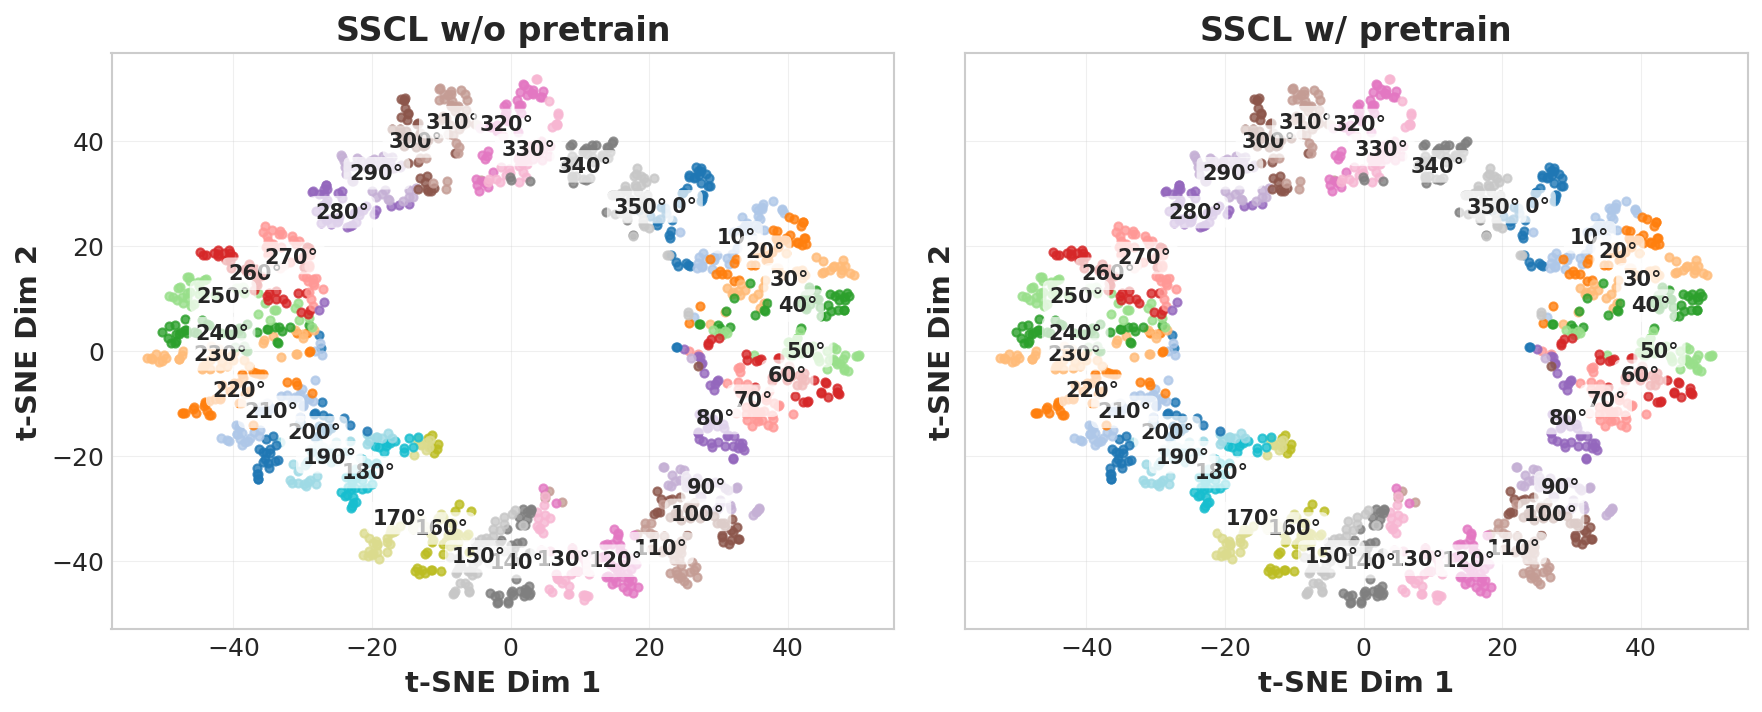

(<Figure size 1800x750 with 2 Axes>,
 array([<Axes: title={'center': 'SSCL w/o pretrain'}, xlabel='t-SNE Dim 1', ylabel='t-SNE Dim 2'>,
        <Axes: title={'center': 'SSCL w/ pretrain'}, xlabel='t-SNE Dim 1', ylabel='t-SNE Dim 2'>],
       dtype=object))

In [41]:
# tsne_result_list = [tsne_result_a, tsne_result_b, tsne_result_c, ...]
plot_tsne_clusters_multi(
    rx_labels=rx_labels,
    tsne_results=[tsne_result, tsne_result],
    titles=["SSCL w/o pretrain", "SSCL w/ pretrain"],
    ncols=2,
    share_axes=True,
    show_legend=False,
)

## Performance on SoClas, AFPILD, and AV16.3 Datasets

We further evaluate the proposed method on three real-world datasets, each corresponding to a distinct robotic audition task: event localization, pedestrian localization, and speaker localization.

---

### SoClas Dataset [1]

The SoClas dataset contains acoustic recordings of diverse sound events for joint sound localization and classification.

In this setup:
- The microphone array is placed at the center of the room.
- The sound source is positioned at a fixed distance of 1.5 meters.
- The azimuth angle varies from 1° to 360° with a 5° interval.

For each angle, 80% of the samples are randomly selected for training, and the remaining 20% are used for testing.

This dataset evaluates the robustness of the proposed method under event-level sound localization scenarios.

---

### AFPILD Dataset [2]

The AFPILD dataset focuses on pedestrian localization using footstep sounds recorded by a microphone array and LiDAR sensor.

We directly adopt the official training/testing split provided by the dataset authors.  
All experiments are conducted using the cloth covariant type (`covariant_type='cloth'`), following the standard evaluation protocol.

This dataset reflects a realistic robotic perception task for surrounding pedestrian localization.

---

### AV16.3 Dataset [3]

AV16.3 is a widely used benchmark dataset for speaker localization and tracking.

Following the AV3T preprocessing pipeline,  
we process the raw data and adopt the following split:

- **Testing sequences:** seq8 and seq18  
- **Training sequences:** remaining sequences  

This dataset evaluates the generalization capability of the proposed method in multi-speaker indoor environments.

---

### References

[1] X. Qian et al., “SLoClas: A database for joint sound localization and classification,” O-COCOSDA, 2021.  
[2] S. Wu et al., “AFPILD: Acoustic footstep dataset collected using one microphone array and LiDAR sensor for person identification and localization,” *Information Fusion*, 2024.  
[3] G. Lathoud et al., “AV16.3: An audio-visual corpus for speaker localization and tracking,” MLMI, 2004.

### Model Testing
Here we give an example for AV16.3 dataset under known setting (M=1,2)

In [35]:
from dataset.data_loader import AV16_Dataset
input_channel = 32
mic_offset = np.array([
[-0.10000,  0.40000,  0.0],
[-0.07071,  0.32929,  0.0],
[ 0.00000,  0.30000,  0.0],
[ 0.07071,  0.32929,  0.0],
[ 0.10000,  0.40000,  0.0],
[ 0.07071,  0.47071,  0.0],
[ 0.00000,  0.50000,  0.0],
[-0.07071,  0.47071,  0.0],
[-0.10000, -0.40000,  0.0],
[-0.07071, -0.47071,  0.0],
[ 0.00000, -0.50000,  0.0],
[ 0.07071, -0.47071,  0.0],
[ 0.10000, -0.40000,  0.0],
[ 0.07071, -0.32929,  0.0],
[ 0.00000, -0.30000,  0.0],
[-0.07071, -0.32929,  0.0],
])


In [43]:
for M in range(1,3):
    print(f"Test under {M} source setting")
    data_dir_val  = f'/media/kemove/T9/sound_source_loc/AV1_processed/{M}p/test'
    val_dataset   = AV16_Dataset(data_dir_val,mic_offsets=mic_offset,noise_aug=False,subset="val")
    val_loader    = DataLoader(val_dataset, batch_size=1, shuffle=False, num_workers=4)
    model         = NeuralMusic(N, T, M,device=device,input_channel=input_channel).to(device)
    model_path    = f'/home/Disk/yyz/deepmusic++/New_exp/saved_av16_attention_new/ours_1.0_1_{M}/best_model'
    model.load_state_dict(torch.load(model_path),strict=False)
    model.eval()
    predictions,ground_truths,probs = evaluate_ours_known(val_loader,M,device)
    save_dir = "./results"
    os.makedirs(save_dir,exist_ok=True)
    np.save(f"./results/AV163_prediction_{M}",predictions)
    np.save(f"./results/AV163_probs_{M}",probs)

Test under 1 source setting
[OK] AV16 indexed 360 samples from /media/kemove/T9/sound_source_loc/AV1_processed/1p/test


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 360/360 [00:03<00:00, 101.31it/s]


The MAAE is 7.562608167860243
Test under 2 source setting
[OK] AV16 indexed 1156 samples from /media/kemove/T9/sound_source_loc/AV1_processed/2p/test


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1156/1156 [00:10<00:00, 108.62it/s]

The MAAE is 11.15506182079909


### Visualization on AV16.3

This section presents qualitative visualization results on the AV16.3 dataset. Note that slight spatial misalignments may occur due to calibration inaccuracies.(only show the plots for M=1)

[OK] indexed 360 samples
[META] seq08-1p-0100 | seq08_0002 | idx=1


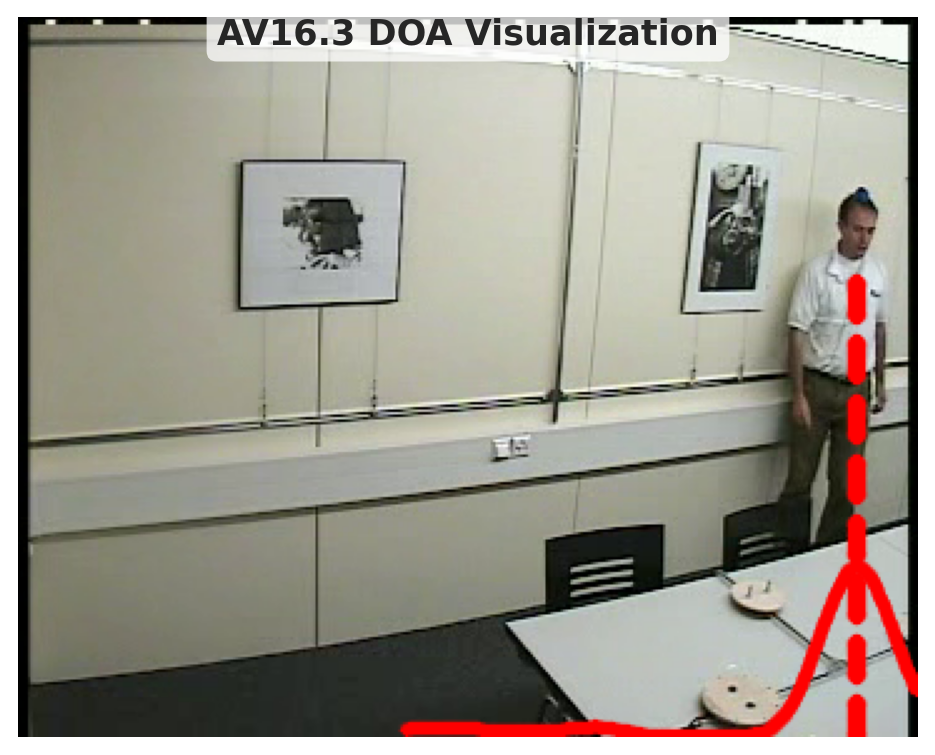

(<Figure size 900x720 with 1 Axes>, <Axes: >)

In [43]:
from utlis.jupyter_utils import visualize_av16_multi_methods, show_canvas
ROOT_DIR = "/media/kemove/T9/sound_source_loc/AV1_processed/1p/test"
P_PATH   = "/home/Disk/yyz/deepmusic++/AV3T/data/AV16.3/P1.mat"
INDEX    = 1
METHODS = {
    "ours": {
        "pred": "./results/AV163_prediction_1.npy",
        "prob": "./results/AV163_probs_1.npy",
    }}
canvas, meta = visualize_av16_multi_methods(
    root_dir=ROOT_DIR,
    p_path=P_PATH,
    methods=METHODS,
    index=INDEX,
)
show_canvas(
    canvas,
    title="AV16.3 DOA Visualization",
    # meta=meta,
    figsize_by_width=5,
    dpi=180,
    add_info=True,
)